**1. Считайте датасет из файла train.csv (это данные о выживаемости на Титанике)**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

table = pd.read_csv('train.csv')
table.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


**2. Визуализируйте распределение значений признаков Survived, Pclass, Age, Sex. Parch**

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

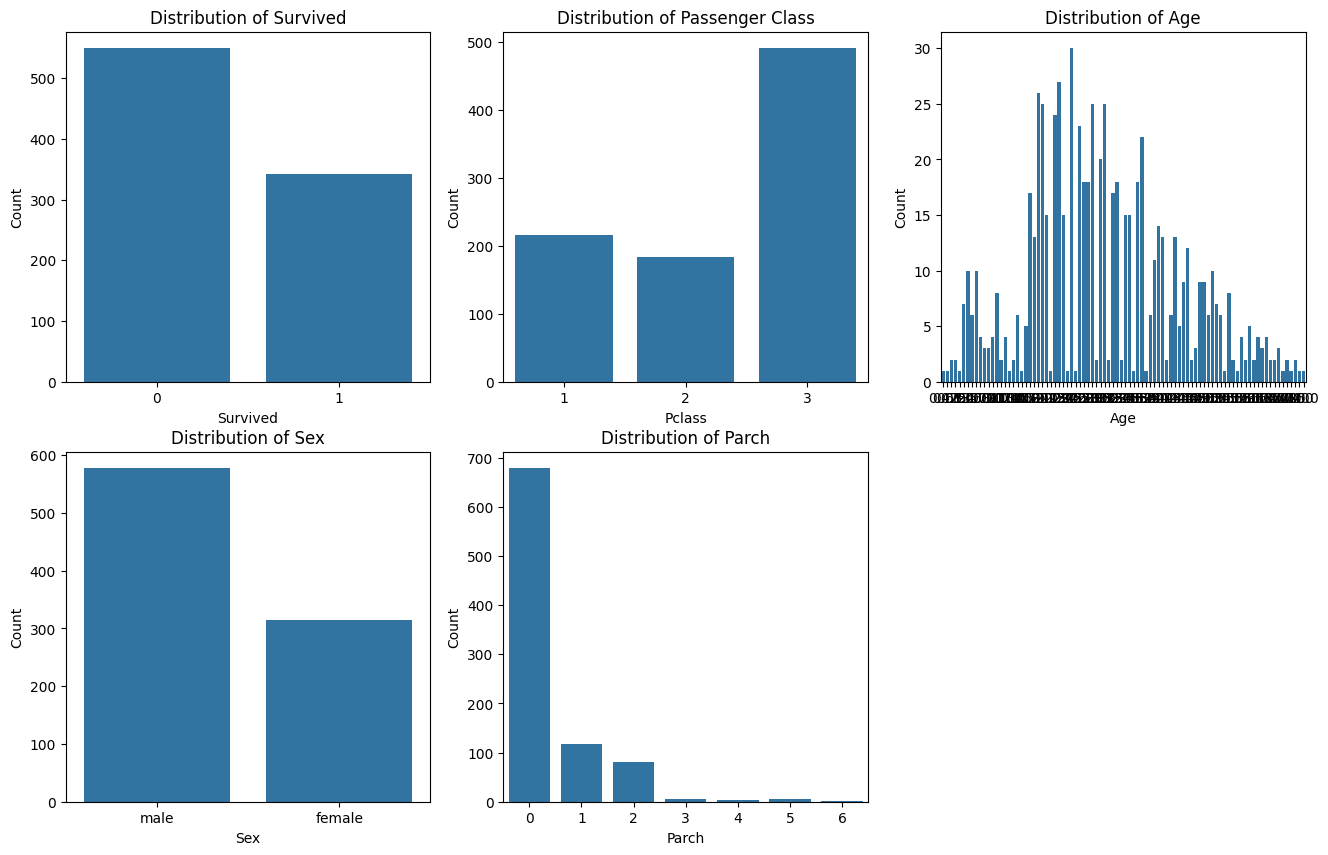

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.countplot(data=table, x="Survived", ax=axes[0,0])
axes[0, 0].set_title("Distribution of Survived")
axes[0, 0].set_xlabel("Survived")
axes[0, 0].set_ylabel("Count")

sns.countplot(data=table, x="Pclass", ax=axes[0,1])
axes[0, 1].set_title("Distribution of Passenger Class")
axes[0, 1].set_xlabel("Pclass")
axes[0, 1].set_ylabel("Count")

sns.countplot(data=table, x="Age", ax=axes[0,2])
axes[0, 2].set_title("Distribution of Age")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Count")

sns.countplot(data=table, x="Sex", ax=axes[1,0])
axes[1, 0].set_title("Distribution of Sex")
axes[1, 0].set_xlabel("Sex")
axes[1, 0].set_ylabel("Count")

sns.countplot(data=table, x="Parch", ax=axes[1,1])
axes[1, 1].set_title("Distribution of Parch")
axes[1, 1].set_xlabel("Parch")
axes[1, 1].set_ylabel("Count")

axes[1, 2].axis("off")

#plt.tight_layout()

**3. Постройте график типа boxplot для столбца Age**

Text(0.5, 0, 'Age')

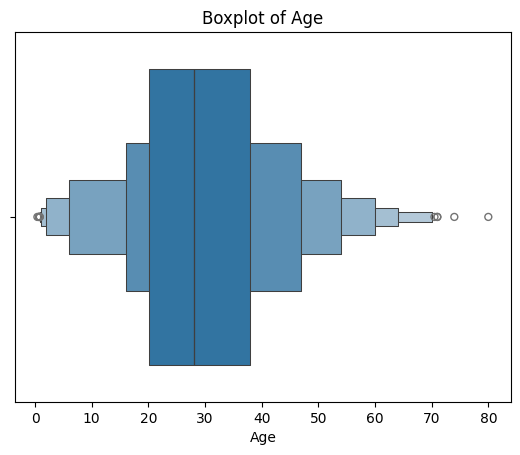

In [35]:
plt.figure()
sns.boxenplot(x=table["Age"])
plt.title("Boxplot of Age")
plt.xlabel("Age")


**4. Проинтепретируйте полученный график**

На графике видно, что медианный возраст пассажиров составляет примерно 28 лет. Основная часть значений находится примерно в диапазоне от 20 до 38 лет, следовательно, большинство пассажиров были молодыми или людьми среднего возраста. Распределение имеет небольшую правостороннюю асимметрию, так как верхний “ус” длиннее, и наблюдаются выбросы среди более пожилых пассажиров. Эти выбросы соответствуют возрастам примерно старше 70 лет. Также в выборке есть дети и подростки, однако основная масса пассажиров относится ко взрослой возрастной группе.

**5. Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах**

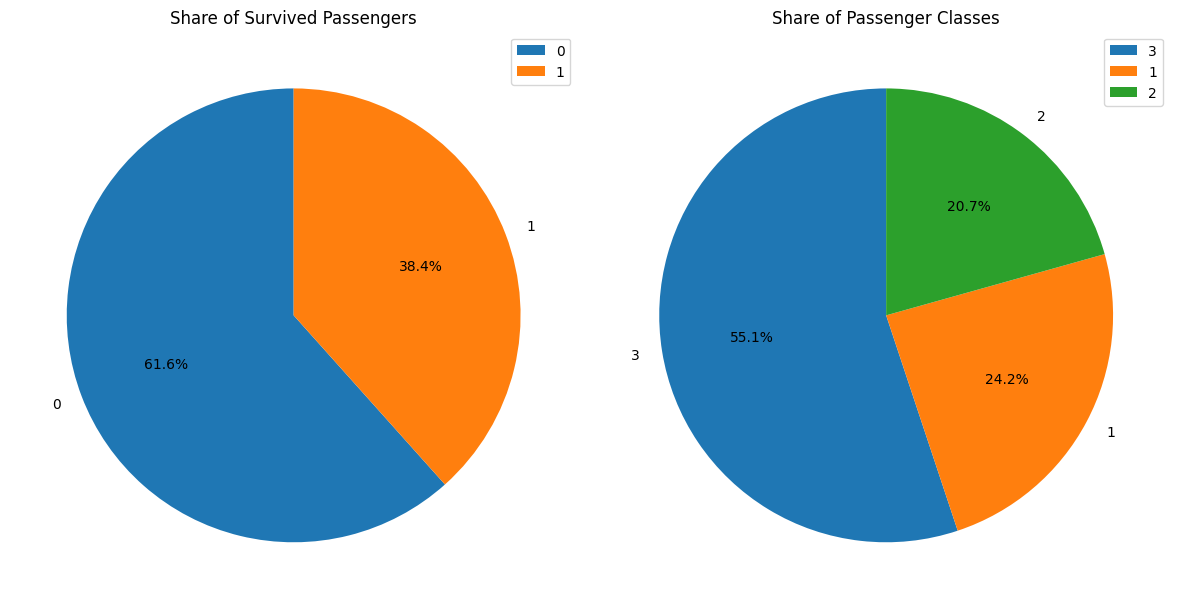

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

table["Survived"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", ax=axes[0], startangle=90, legend=True
)
axes[0].set_title("Share of Survived Passengers")
axes[0].set_ylabel("")

table["Pclass"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", ax=axes[1], startangle=90, legend=True
)
axes[1].set_title("Share of Passenger Classes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**6. Постройте график типа pairplot для всех числовых переменных датасета**

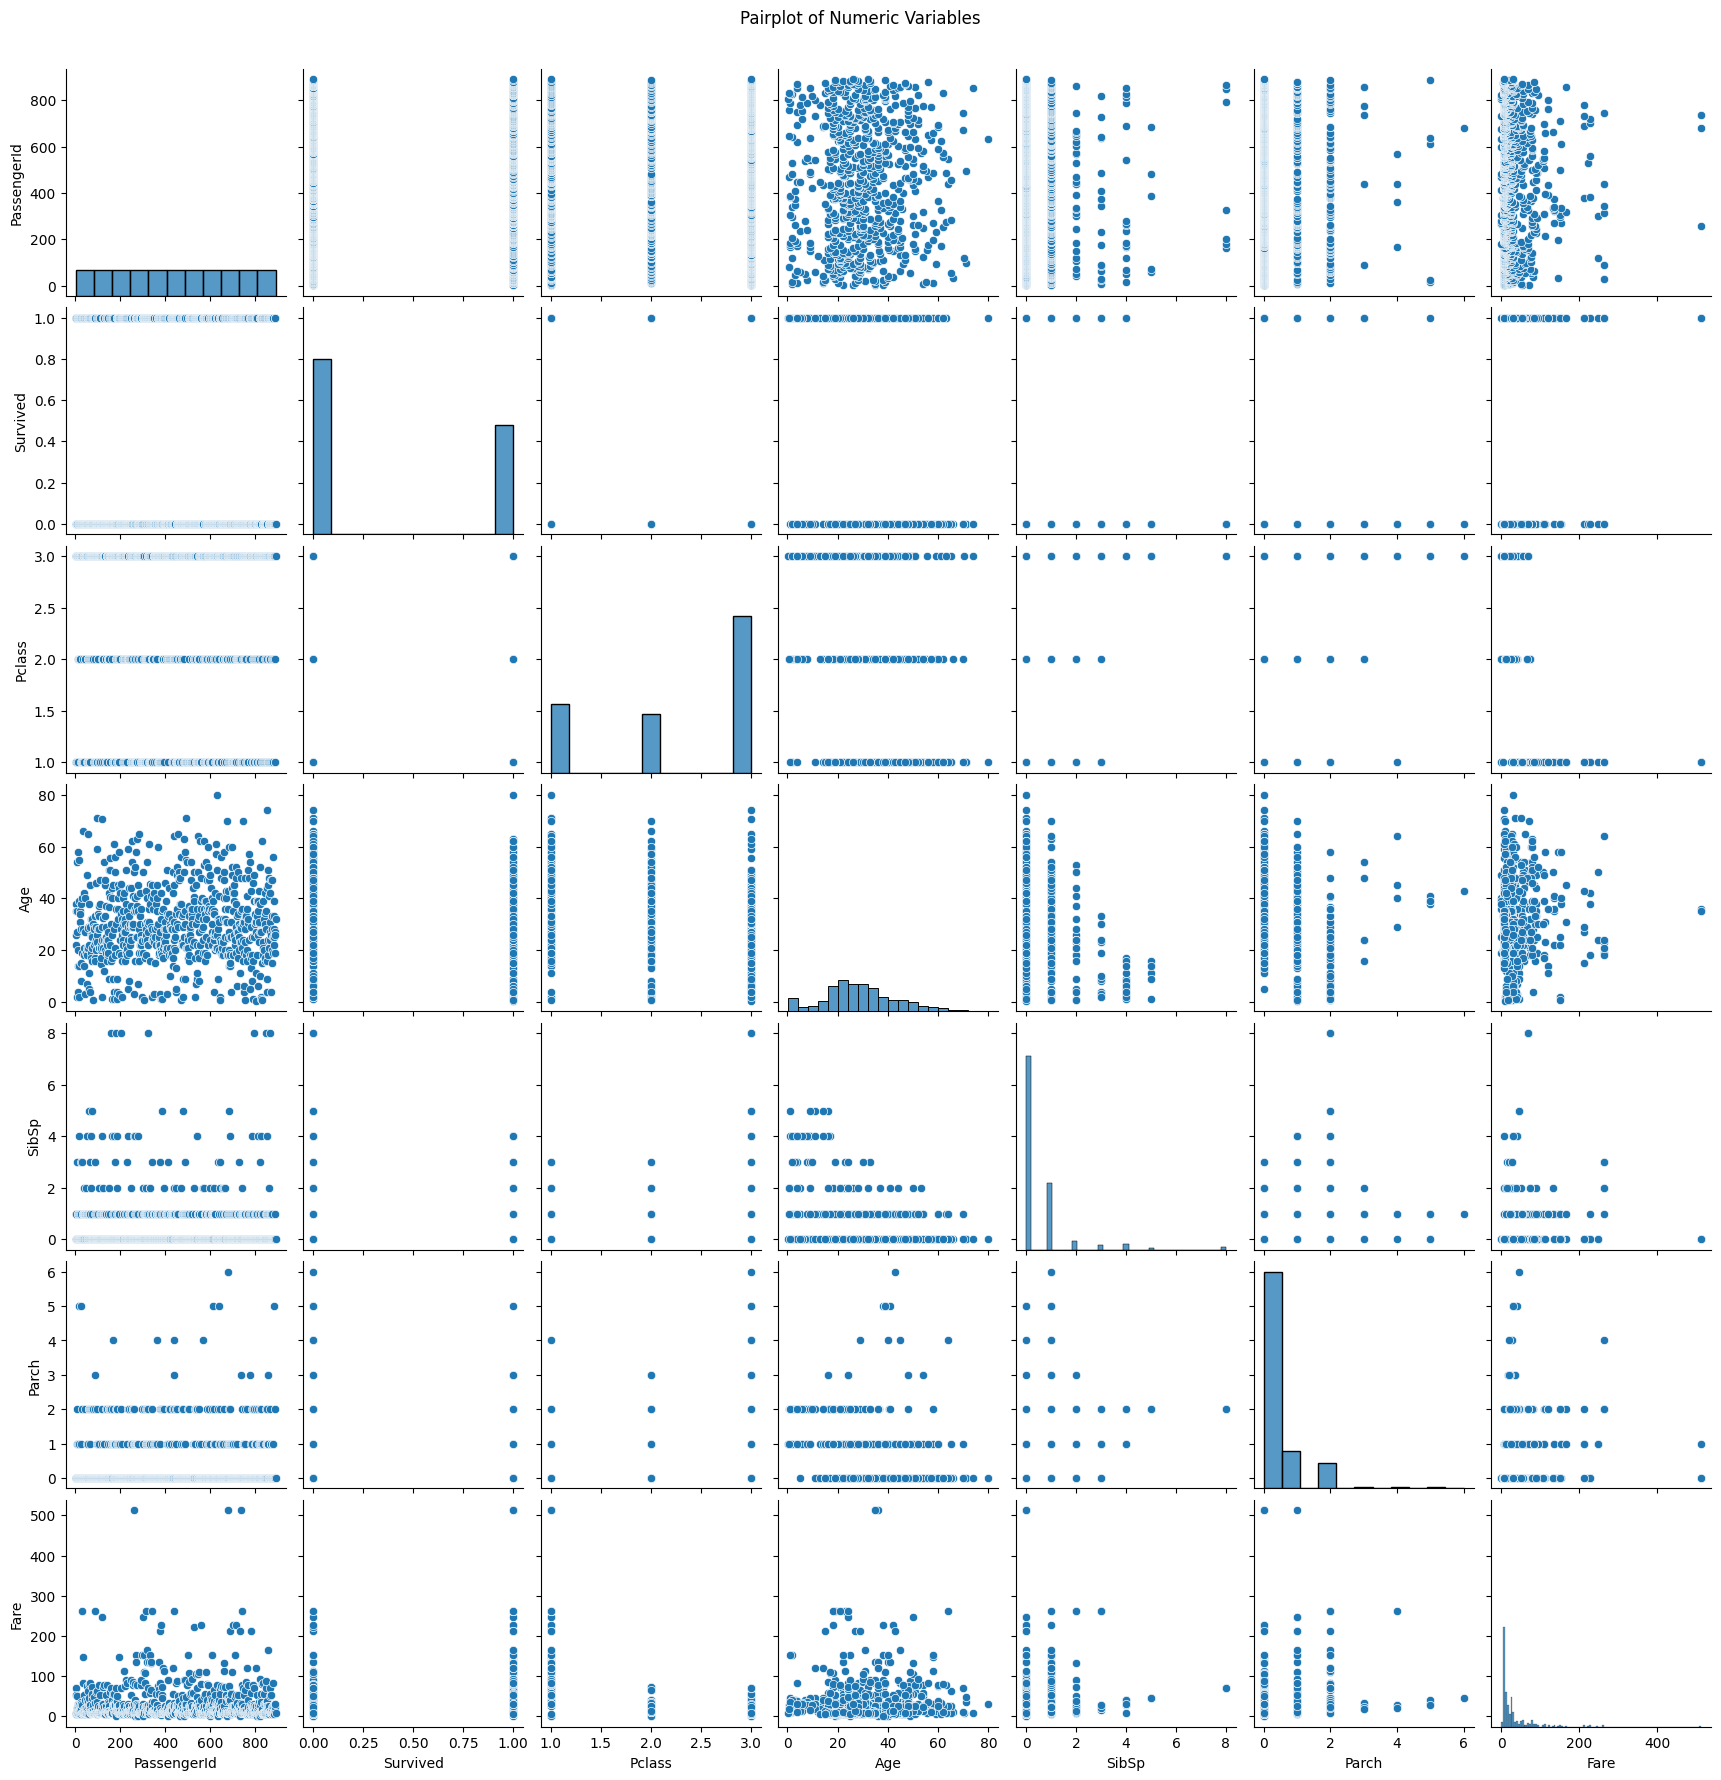

In [46]:
numeric_table = table.select_dtypes(include=["int64", "float64"])

sns.pairplot(numeric_table)
plt.suptitle("Pairplot of Numeric Variables", y=1.02)
plt.show()

**7. Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе**

In [48]:
sunburst_data = table.groupby(["Pclass", "Sex"]).size().reset_index(name="Count")

fig = px.sunburst(
    sunburst_data,
    path=["Pclass", "Sex"],
    values="Count",
    title="Sunburst Plot of Passengers by Class and Sex"
)

fig.show()